In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# --- 1. Load Raw Data ---
df_raw = pd.read_csv('tv_shows_raw.csv')

# --- 2. Clean Data (Matching src/preprocessing.py logic) ---
df_clean = df_raw.copy()

In [3]:
column_mapping = {
    'Title': 'title',
    'EpisodeDuration(in Minutes)': 'runtime_mins',
    'Genres': 'primary_genre',
    'Actors': 'key_cast',
    'Rating': 'imdb_rating',
    'Years': 'release_year',
    'Votes': 'no_of_votes'
}
df_clean = df_clean.rename(columns=column_mapping)

In [5]:
# Extract primary genre & clean release year
df_clean['primary_genre'] = df_clean['primary_genre'].fillna('Unknown').apply(lambda x: str(x).split(',')[0].strip())
df_clean['release_year'] = df_clean['release_year'].astype(str).str.extract(r'(\d{4})')[0]
df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')
df_clean['release_year'] = df_clean['release_year'].fillna(df_clean['release_year'].median()).astype(int)

In [6]:
# Clean runtime & handle missing ratings
df_clean['runtime_mins'] = pd.to_numeric(df_clean['runtime_mins'], errors='coerce').fillna(df_clean['runtime_mins'].median())
df_clean['imdb_rating'] = pd.to_numeric(df_clean['imdb_rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['imdb_rating'])
df_clean = df_clean[(df_clean['imdb_rating'] >= 1.0) & (df_clean['imdb_rating'] <= 10.0)]

In [7]:
# Target Categorization
def bin_rating(rating):
    if rating < 7.0:
        return 'Low'
    if rating < 8.0:
        return 'Moderate'
    return 'High'

df_clean['success_category'] = df_clean['imdb_rating'].apply(bin_rating)

# --- 3. Plot Generation (EDA) ---

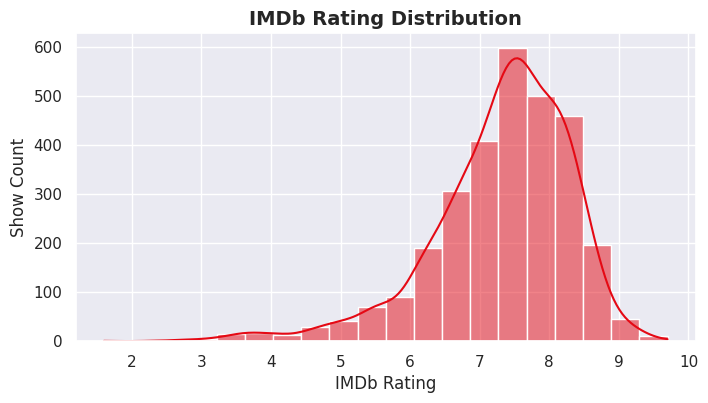

In [8]:
sns.set_theme(style="darkgrid")

# Chart 1: Continuous Rating Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['imdb_rating'], kde=True, bins=20, color='#E50914')
plt.title('IMDb Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Rating')
plt.ylabel('Show Count')
plt.show()

/tmp/ipykernel_1555/2172897664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='success_category', order=['Low', 'Moderate', 'High'], palette=['#FF4B4B', '#FFAA00', '#00CC96'])


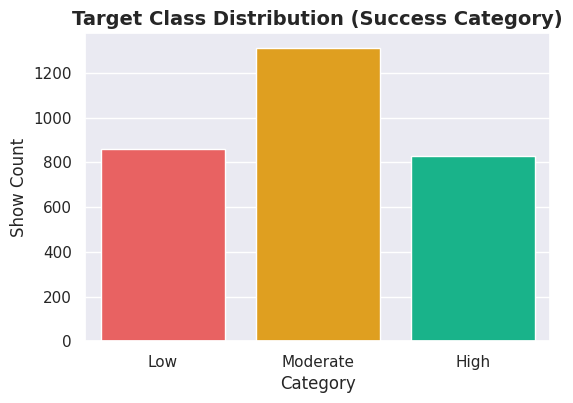

In [10]:
# Chart 2: Success Category Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='success_category', order=['Low', 'Moderate', 'High'], palette=['#FF4B4B', '#FFAA00', '#00CC96'])
plt.title('Target Class Distribution (Success Category)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Show Count')
plt.show()

/tmp/ipykernel_1555/3125795773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['primary_genre'].isin(top_genres)], x='primary_genre', y='imdb_rating', palette='Set2')


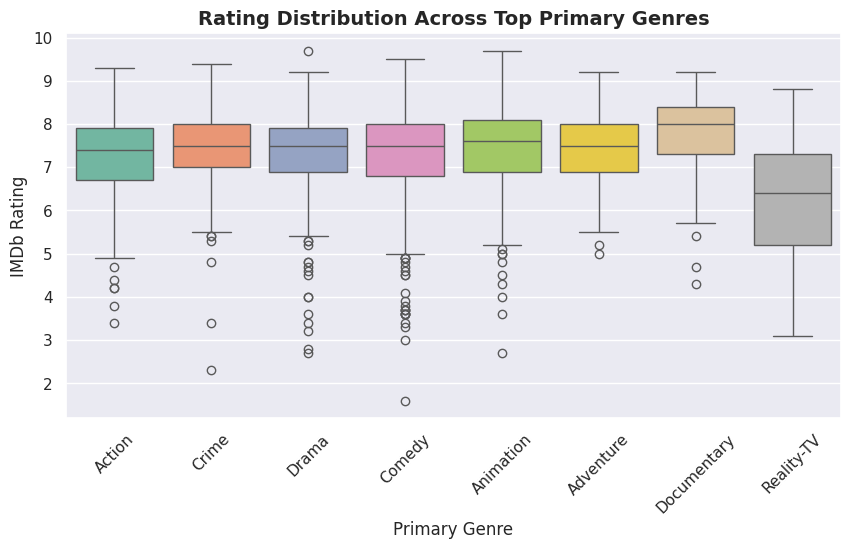

In [11]:
# Chart 3: Rating by Primary Genre
plt.figure(figsize=(10, 5))
top_genres = df_clean['primary_genre'].value_counts().head(8).index
sns.boxplot(data=df_clean[df_clean['primary_genre'].isin(top_genres)], x='primary_genre', y='imdb_rating', palette='Set2')
plt.title('Rating Distribution Across Top Primary Genres', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Primary Genre')
plt.ylabel('IMDb Rating')
plt.show()